# COMP 3800 Project 1

Mason Coleman

Fall 2026

### 1. Dataset Description and Investigation Questions

**Dataset**: Top Github Repositories 2026
- Shape: 627 rows x 17 columns
- Lists the most popular GitHub repos (based on number of stars) in 2026
- Includes other useful features about each repo such as language, license type, size (in KBs), etc.
- Link: https://www.kaggle.com/datasets/elvisbui/top-github-repositories-2026

**Main Inquiry**: What influence does open source licensing, development language usage, and constant innovation have on widespread software adoption?
1. What are the different license categories and how do they compare to each other?
2. What programming languages hold the largest share of repositories?
3. What is the relationship between number of stars and number of forks?

#### Getting Familiar With The Data

In [29]:
# Import the necessary modules and libraries
import pandas as pd
from matplotlib import pyplot as plt

# Create dataframe from data file and read the first 10 rows
original_df = pd.read_csv("top_github_repos_2026.csv")
original_df.head(10)

,name,description,language,stars,forks,open_issues,watchers,created_at,updated_at,topics,license,is_fork,has_wiki,archived,size_kb,default_branch,homepage
0,codecrafters-io/build-your-own-x,Master programming by recreating your favorite...,Markdown,487662,45893,462,487662,2018-05-09,2026-04-09,awesome-list|free|programming|tutorial-code|tu...,NaN,False,False,False,1201,master,https://codecrafters.io
1,sindresorhus/awesome,😎 Awesome lists about all kinds of interesting...,NaN,453320,34056,59,453320,2014-07-11,2026-04-09,awesome|awesome-list|lists|resources|unicorns,CC0-1.0,False,False,False,1535,main,NaN
2,freeCodeCamp/freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,TypeScript,442235,44192,200,442235,2014-12-24,2026-04-09,careers|certification|community|curriculum|d3|...,BSD-3-Clause,False,False,False,559313,main,https://contribute.freecodecamp.org
3,public-apis/public-apis,A collective list of free APIs,Python,420283,45730,1216,420283,2016-03-20,2026-04-09,api|apis|dataset|development|free|list|lists|o...,MIT,False,False,False,4962,master,https://APILayer.com/?utm_source=Github&utm_me...
4,EbookFoundation/free-programming-books,:books: Freely available programming books,Python,385209,66095,79,385209,2013-10-11,2026-04-09,books|education|hacktoberfest|list|resource,CC-BY-4.0,False,False,False,21200,main,https://ebookfoundation.github.io/free-program...
5,kamranahmedse/developer-roadmap,"Interactive roadmaps, guides and other educati...",TypeScript,352538,43891,4,352538,2017-03-15,2026-04-09,angular-roadmap|backend-roadmap|blockchain-roa...,NOASSERTION,False,True,False,360000,master,https://roadmap.sh
6,openclaw/openclaw,Your own personal AI assistant. Any OS. Any Pl...,TypeScript,352335,70995,17831,352335,2025-11-24,2026-04-09,ai|assistant|crustacean|molty|openclaw|own-you...,MIT,False,False,False,426353,main,https://openclaw.ai
7,donnemartin/system-design-primer,Learn how to design large-scale systems. Prep ...,Python,341930,55250,528,341930,2017-02-26,2026-04-09,design|design-patterns|design-system|developme...,NOASSERTION,False,True,False,11277,master,NaN
8,jwasham/coding-interview-university,A complete computer science study plan to beco...,NaN,340596,81900,105,340596,2016-06-06,2026-04-09,algorithm|algorithms|coding-interview|coding-i...,CC-BY-SA-4.0,False,False,False,22700,main,NaN
9,vinta/awesome-python,"An opinionated list of Python frameworks, libr...",Python,291432,27615,20,291432,2014-06-27,2026-04-09,awesome|collections|python|python-frameworks|p...,NOASSERTION,False,False,False,5262,master,https://awesome-python.com/


### 2. Data Cleaning

In [30]:
# A. Select specific features to work with
selected_features = ["name", "language", "stars", "forks", "license"]
slimmed_df = original_df[selected_features]

# B. Check for missing values and show results
print("Checking for missing values in each column:\n")
for column in slimmed_df.columns:
    missing_percent = slimmed_df[column].isnull().sum() / slimmed_df.shape[0]
    print(f"The {column} column is missing {round(missing_percent, 2)}% of its values.")

# Remove rows with missing values and display shape changes
removeNulls_df = slimmed_df.dropna(axis=0, how='any', subset=None, inplace=False)
print(f"\nShape before dropping missing values: {slimmed_df.shape}")
print(f"Shape after dropping missing values: {removeNulls_df.shape}")

Checking for missing values in each column:

The name column is missing 0.0% of its values.
The language column is missing 0.03% of its values.
The stars column is missing 0.0% of its values.
The forks column is missing 0.0% of its values.
The license column is missing 0.05% of its values.

Shape before dropping missing values: (627, 5)
Shape after dropping missing values: (578, 5)


In [31]:
# C. Remove any duplicates and display shape changes
removeDuplicates_df = removeNulls_df.drop_duplicates(subset=['name'], keep='first')
print(f"Shape before dropping duplicates: {removeNulls_df.shape}")
print(f"Shape after dropping duplicates: {removeDuplicates_df.shape}")


Shape before dropping duplicates: (578, 5)
Shape after dropping duplicates: (578, 5)


In [32]:

# D. Check column data types
for column in removeDuplicates_df.columns:
    print(f"{column} column: {removeDuplicates_df[column].dtype}")

name column: str
language column: str
stars column: int64
forks column: int64
license column: str


In [33]:
# E. Verify consistency of categorical values
print(removeDuplicates_df['language'].value_counts())
print()
print(removeDuplicates_df['license'].value_counts())

language
TypeScript          107
Python              101
Go                   90
JavaScript           88
Rust                 87
Java                 81
Shell                 5
HTML                  4
C++                   4
C                     2
MDX                   2
Swift                 2
Dart                  1
Batchfile             1
C#                    1
Jupyter Notebook      1
Dockerfile            1
Name: count, dtype: int64

license
MIT             238
Apache-2.0      156
NOASSERTION      86
AGPL-3.0         30
GPL-3.0          26
BSD-3-Clause     13
Unlicense         6
MPL-2.0           6
CC-BY-SA-4.0      4
CC-BY-4.0         3
ISC               2
CC0-1.0           2
BSD-2-Clause      2
GPL-2.0           2
LGPL-3.0          1
WTFPL             1
Name: count, dtype: int64


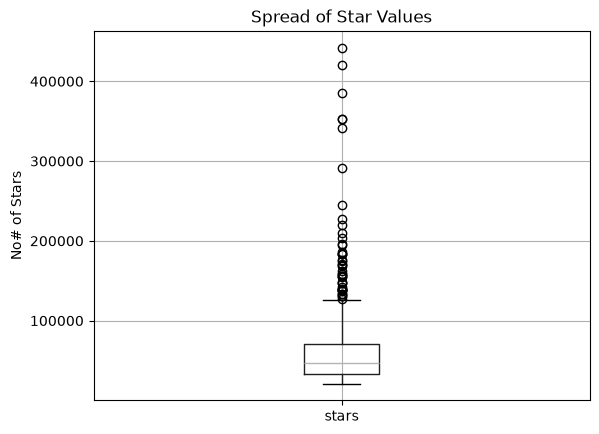

In [34]:
# F. Check for outliers in numerical variables
# Stars Column
removeDuplicates_df.boxplot(column='stars')
plt.title("Spread of Star Values")
plt.ylabel("No# of Stars")
plt.show()

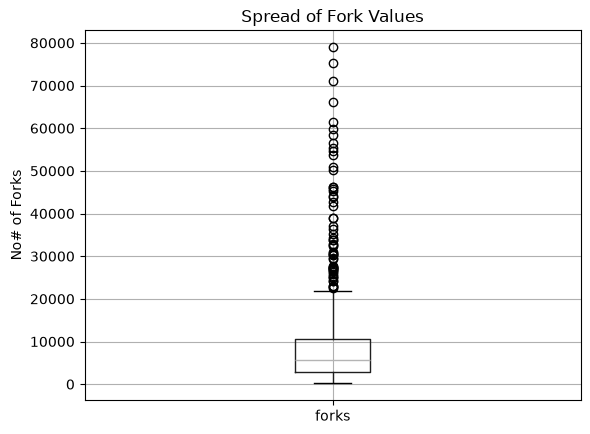

In [35]:
# Forks Column
removeDuplicates_df.boxplot(column='forks')
plt.title("Spread of Fork Values")
plt.ylabel("No# of Forks")
plt.show()

### 3. Exploratory Data Analysis and Interpretation

##### What are the different license categories and how do they compare to each other?

In [36]:
# Table showing license categories and their frequencies
license_df = removeDuplicates_df['license'].value_counts().to_frame()
license_df

,count
license,
MIT,238
Apache-2.0,156
NOASSERTION,86
AGPL-3.0,30
GPL-3.0,26
BSD-3-Clause,13
Unlicense,6
MPL-2.0,6
CC-BY-SA-4.0,4


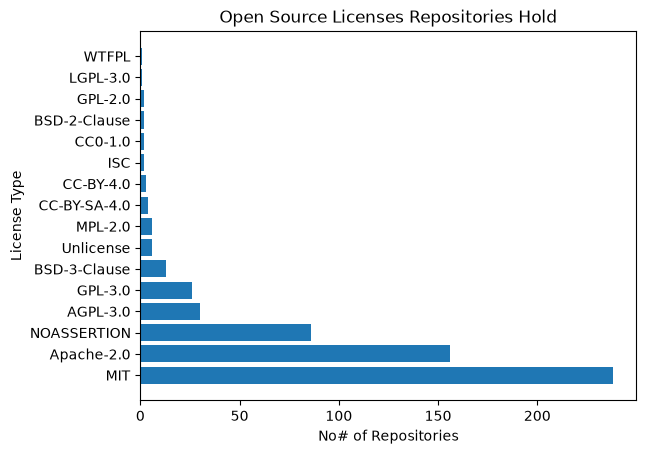

In [37]:
# Create a horizontal bar chart summarizing the number of repos that each license category supports
licenses = [
"MIT",
"Apache-2.0",
"NOASSERTION",
"AGPL-3.0",
"GPL-3.0",
"BSD-3-Clause",
"Unlicense",
"MPL-2.0",
"CC-BY-SA-4.0",
"CC-BY-4.0",
"ISC",
"CC0-1.0",
"BSD-2-Clause",
"GPL-2.0",
"LGPL-3.0",
"WTFPL"
]

plt.barh(licenses, license_df.iloc[:, 0])
plt.title("Open Source Licenses Repositories Hold")
plt.xlabel('No# of Repositories')
plt.ylabel('License Type')
plt.show()

The horizontal bar chart above shows the different categories of open source licenses that repositories in the dataset hold. The most obvious trend in the graph is the MIT license's popularity with over 200 repositories. Apache 2.0 is not too far behind. Most other licenses fall significantly behind. For example, LGPL-3.0 and BSD-2-Clause licenses are among the rarest representing 1 and 2 repositories respectively. The MIT and Apache 2.0 licenses are permissive by nature, which means works derived from code doesn't have to be made open-source, making it easy for others to adopt. On the other hand, MPL 2.0, GPL 2.0 and 3.0, and other less common licenses are protected by copyleft. Any work that is derived from code under these licenses must be made open-source, restricting certain use cases, especially commercial software development. Licenses that are not well-known (e.g., WTFPL) are not likely to become popular or widely used.

##### What programming languages hold the largest share of repositories?

In [38]:
# Table showing programming languages and their relative frequencies
language_df = removeDuplicates_df['language'].value_counts(normalize=True).to_frame()
language_df

,proportion
language,
TypeScript,0.185121
Python,0.174740
Go,0.155709
JavaScript,0.152249
Rust,0.150519
Java,0.140138
Shell,0.008651
HTML,0.006920
C++,0.006920


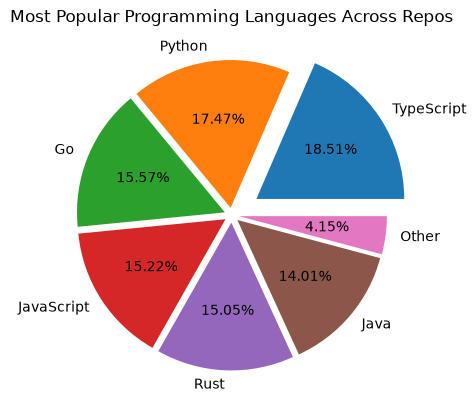

In [39]:
# Create dataframe with most popular languages and 'other' row
largest_languages = language_df.iloc[0:6, 0]
other_row = [language_df.iloc[6:, 0].sum()]
largest_languages.loc[6] = other_row[0]

languages = [
    "TypeScript",
    "Python",
    "Go",
    "JavaScript",
    "Rust",
    "Java",
    "Other"
]

# Create a pie chart summarizing the portion of repos that each language powers
plt.pie(largest_languages.to_frame().iloc[:, 0], explode=[0.2, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05], labels=languages, autopct='%.2f%%')
plt.title("Most Popular Programming Languages Across Repos")
plt.show()

This pie chart shows the various computer languages powering the repositories in the dataset. The largest portion of the repositories (nearly 19%) are written in TypeScript that builds upon and in turn compiles into JavaScript, which itself is the most popular programming language on the web. TypeScript's popularity can be attributed to the language's type checking system, which catches bugs when a program is compiled. Classic JavaScript warns about errors in a program when it is executed. The type checking prevents common errors and allows TypeScript code bases to scale over time as more code and engineers are introduced. Go, Rust, and Java also utilize type checking systems, making them popular scalable languages as well. The general-purpose Python language closely trails TypeScript with 17.47%. Loved for its simple syntax, versatility, and large community, Python fuels many areas including web development, data science, artificial intelligence, and more. All the other languages (C#, HTML, etc.) combined represent only 4.15% of the top GitHub repositories. HTML is used for structuring web content, so it occupies a specialized niche and isn't used in many other contexts.

##### What is the relationship between number of stars and number of forks?

In [40]:
# Get basic descriptive statistics about stars
print("Star Statistics:")
removeDuplicates_df['stars'].describe()


Star Statistics:


count       578.000000
mean      61652.108997
std       50471.432570
min       21089.000000
25%       32843.750000
50%       46993.500000
75%       70332.750000
max      442235.000000
Name: stars, dtype: float64

In [41]:
# Get basic descriptive statistics about forks
print("Fork Statistics:")
removeDuplicates_df['forks'].describe()

Fork Statistics:


count      578.000000
mean      9541.897924
std      11567.633966
min        247.000000
25%       2864.500000
50%       5715.000000
75%      10489.500000
max      79006.000000
Name: forks, dtype: float64

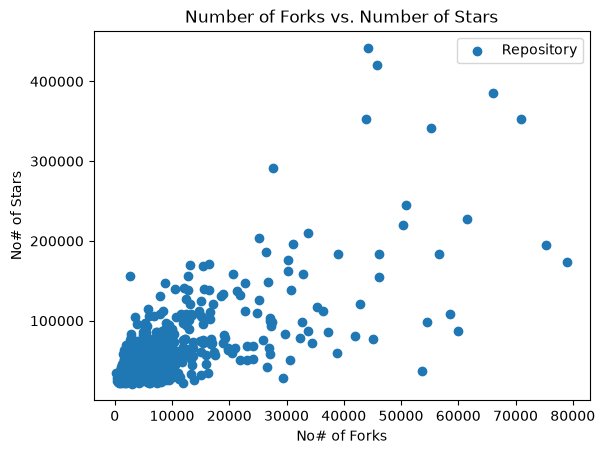

In [42]:
# Create scatter plot graph to examine relationship between number of forks and number of stars
plt.scatter(removeDuplicates_df.iloc[:, 3], removeDuplicates_df.iloc[:, 2])
plt.title("Number of Forks vs. Number of Stars")
plt.xlabel('No# of Forks')
plt.ylabel('No# of Stars')
plt.legend(['Repository'], loc='upper right')
plt.show()

The scatterplot shows a moderately strong, positive, linear relationship between number of stars and number of forks. As the number of forks increases, the number of stars tends to increase as well. Many repositories are clustered towards the left side of the graph because the average star number is around 61652, and the average number of forks is nearly 9542. Forking a repository allows for changes to be made without altering the original repository. This allows people to propose ideas and apply them to a project without worrying about breaking functionality. When a project is open to different ideas, especially ones that make the GitHub project better overtime, popularity for the repository tends to go up. There are roughly 7 outliers where the number of stars is unusually high. Perhaps these repositories are experiencing widespread adoption because they excel at meeting the needs of the community they were built for.

### 4. Main Findings, Shortcomings, and Further Exploration

In conclusion, the license a repositry holds, the programming language it's written in, and the number of modifications have a profound impact on the repository's success and popularity:
- The popular MIT and Apache 2.0 licenses offer the flexibility and freedom that most users desire to share and make improvements to software.
- Writing code in a scalable (i.e., TypeScript), easy-to-learn, and versatile (i.e., Python) language also contributes to popularity as people can catch on quickly to a project's features, and the project itself can support the weight of new team members and code.
- A project that forks often is a project that improves often. When a project brings diverse ideas together, improvements that benefit all parties involved are inevitable. Typically, the more forks a repository has, the more stars it has.

One important insight that I failed to find from the results was the overall trend of popularity during a repository's lifetime. In other words, how did the number of stars on a project change from year to year? I would need another dataset about a specific repository (perhaps the one with the most stars) with features such as year and the number of stars for that year. Then, I could graph the trend using a line graph with year as the x-axis and number of stars as the y-axis.